# Painting Classifier: KNN, Softmax Regression, and MLP Development

This notebook develops three models for classifying paintings from survey responses: K-Nearest Neighbours, Softmax Regression, and a Multi-Layer Perceptron.

**Setup:** Upload `training_data_202601.csv` to the working directory before running.

In [1]:
import pandas as pd
import numpy as np
import itertools
import re
import json
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (f1_score, accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier

## 1. Data Loading and Column Definitions

In [2]:
df = pd.read_csv("training_data_202601.csv")
print("Shape:", df.shape)
print("\nClass distribution:")
print(df["Painting"].value_counts())
df.head(3)

Shape: (1686, 16)

Class distribution:
Painting
The Persistence of Memory    562
The Starry Night             562
The Water Lily Pond          562
Name: count, dtype: int64


,unique_id,Painting,"On a scale of 1–10, how intense is the emotion conveyed by the artwork?",Describe how this painting makes you feel.,This art piece makes me feel sombre.,This art piece makes me feel content.,This art piece makes me feel calm.,This art piece makes me feel uneasy.,How many prominent colours do you notice in this painting?,How many objects caught your eye in the painting?,How much (in Canadian dollars) would you be willing to pay for this painting?,"If you could purchase this painting, which room would you put that painting in?","If you could view this art in person, who would you want to view it with?",What season does this art piece remind you of?,"If this painting was a food, what would be?",Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.
0,1,The Persistence of Memory,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,The Persistence of Memory,5.0,"The clocks are burnt on a hot desert, it embod...",4 - Agree,3 - Neutral/Unsure,2 - Disagree,1 - Strongly disagree,2.0,4.0,0,Bathroom,By yourself,Fall,Fries,A country song that contrasts nostalgia for th...
2,3,The Persistence of Memory,7.0,This painting makes me feel dread. The clock r...,4 - Agree,1 - Strongly disagree,1 - Strongly disagree,4 - Agree,4.0,3.0,$5,"Bathroom,Dining room","Coworkers/Classmates,By yourself",Fall,Sardines,A melancholy instrumental with a monotone voic...


In [3]:
TARGET = "Painting"
GROUP_COL = "unique_id"

NUM_COLS = [
    "On a scale of 1–10, how intense is the emotion conveyed by the artwork?",
    "How many prominent colours do you notice in this painting?",
    "How many objects caught your eye in the painting?",
    "How much (in Canadian dollars) would you be willing to pay for this painting?"
]

LIKERT_COLS = [
    "This art piece makes me feel sombre.",
    "This art piece makes me feel content.",
    "This art piece makes me feel calm.",
    "This art piece makes me feel uneasy."
]

CAT_COLS = [
    "If you could purchase this painting, which room would you put that painting in?",
    "If you could view this art in person, who would you want to view it with?",
    "What season does this art piece remind you of?"
]

TEXT_COLS = [
    "Describe how this painting makes you feel.",
    "If this painting was a food, what would be?",
    "Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting."
]

print(f"Numeric: {len(NUM_COLS)}, Likert: {len(LIKERT_COLS)}, "
      f"Categorical: {len(CAT_COLS)}, Text: {len(TEXT_COLS)}")

Numeric: 4, Likert: 4, Categorical: 3, Text: 3


## 2. Data Splitting

We use the same `GroupShuffleSplit` parameters as the Softmax model so that all three models are compared on the same train/test partition. The `unique_id` column serves as the group identifier to keep all responses from the same student together, preventing data leakage.

In [4]:
groups = df[GROUP_COL].copy()
y_all = df[TARGET].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, y_all, groups))

df_train = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

y_train_str = y_all.iloc[train_idx].copy()
y_test_str = y_all.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()

print(f"Train: {len(df_train)}, Test: {len(df_test)}")
print(f"\nTrain class distribution:\n{y_train_str.value_counts()}")
print(f"\nTest class distribution:\n{y_test_str.value_counts()}")

Train: 1347, Test: 339

Train class distribution:
Painting
The Persistence of Memory    449
The Starry Night             449
The Water Lily Pond          449
Name: count, dtype: int64

Test class distribution:
Painting
The Persistence of Memory    113
The Starry Night             113
The Water Lily Pond          113
Name: count, dtype: int64


In [5]:
LABEL_MAP = {
    "The Persistence of Memory": 0,
    "The Starry Night": 1,
    "The Water Lily Pond": 2
}
INT_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}

y_train = y_train_str.map(LABEL_MAP).values
y_test = y_test_str.map(LABEL_MAP).values
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (1347,)
y_test shape: (339,)


## 3. Preprocessing Functions

KNN relies on distances between points, so features with larger ranges would dominate the distance calculation. We normalize all continuous features to zero mean and unit variance (as in Lab 01), multi-hot encode the multi-select categorical features, and apply TF-IDF to text features. Each function returns fitted parameters so the same transformation can be applied to test data.

In [6]:
def extract_rating(response):
    """Parse a Likert response string into an integer. e.g. "4 - Agree" -> 4"""
    if pd.isna(response):
        return None
    match = re.match(r'^(\d+)', str(response))
    return int(match.group(1)) if match else None


def clean_pay_value(val):
    """Parse willingness-to-pay into a float. Handles $, "dollars", etc."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    s = re.sub(r'[$]', '', s)
    s = re.sub(r'\b(cad|dollars?|bucks?)\b', '', s)
    s = s.replace(',', '').strip()
    s = re.sub(r'\.$', '', s)
    try:
        return float(s)
    except ValueError:
        return np.nan


print("extract_rating('4 - Agree'):", extract_rating('4 - Agree'))
print("clean_pay_value('$5'):", clean_pay_value('$5'))
print("clean_pay_value('300 dollars.'):", clean_pay_value('300 dollars.'))
print("clean_pay_value('a'):", clean_pay_value('a'))

extract_rating('4 - Agree'): 4
clean_pay_value('$5'): 5.0
clean_pay_value('300 dollars.'): 300.0
clean_pay_value('a'): nan


In [7]:
PAY_COL = "How much (in Canadian dollars) would you be willing to pay for this painting?"
epsilon = 0.0001


def preprocess_numeric(df, num_cols, likert_cols, fit_params=None):
    """Clean, impute (median), and z-score normalize numeric and Likert features.

    Pay column handling: the raw pay values span ~30 orders of magnitude
    (from 0 to 1e30) due to joke/extreme survey responses. Plain z-score
    normalization produces std ~2.6e28, collapsing all reasonable values to
    the same normalized score (~-0.026). We fix this by:
      1. Clipping negatives to 0 (pay cannot be negative)
      2. Applying log1p (log(1+x)) to compress the range
      3. Then median-imputing and z-score normalizing as usual
    log1p is a fixed transform (no fitted parameters), so there is no
    data-leakage risk. The z-score statistics are still fitted on training
    data only.
    """
    all_cols = num_cols + likert_cols
    result = pd.DataFrame(index=df.index)

    for col in num_cols:
        if col == PAY_COL:
            cleaned = df[col].apply(clean_pay_value)
            # Clip negatives to 0, then log1p to compress extreme outliers
            cleaned = cleaned.clip(lower=0)
            result[col] = np.log1p(cleaned)
        else:
            result[col] = pd.to_numeric(df[col], errors="coerce")

    for col in likert_cols:
        result[col] = df[col].apply(extract_rating).astype(float)

    if fit_params is None:
        fit_params = {}
        for col in all_cols:
            median = result[col].median()
            filled = result[col].fillna(median)
            fit_params[col] = {
                "median": float(median),
                "mean": float(filled.mean()),
                "std": float(filled.std())
            }

    for col in all_cols:
        result[col] = result[col].fillna(fit_params[col]["median"])
        mean = fit_params[col]["mean"]
        std = fit_params[col]["std"]
        result[col] = (result[col] - mean) / (std + epsilon)

    return result[all_cols].values, fit_params

In [8]:
def preprocess_categorical(df, cat_cols, fit_params=None):
    """Multi-hot encode multi-select categorical features (comma-separated)."""
    if fit_params is None:
        fit_params = {}
        for col in cat_cols:
            categories = set()
            for val in df[col].dropna():
                for item in str(val).split(","):
                    item = item.strip()
                    if item:
                        categories.add(item)
            fit_params[col] = sorted(categories)

    arrays = []
    for col in cat_cols:
        cats = fit_params[col]
        cat_to_idx = {c: i for i, c in enumerate(cats)}
        n = len(df)
        hot = np.zeros((n, len(cats)))

        for i, val in enumerate(df[col].values):
            if pd.isna(val):
                continue
            for item in str(val).split(","):
                item = item.strip()
                if item in cat_to_idx:
                    hot[i, cat_to_idx[item]] = 1.0
        arrays.append(hot)

    return np.hstack(arrays), fit_params

In [9]:
def preprocess_text(df, text_cols, fit_params=None):
    """TF-IDF vectorize text features. max_features=50 per column to limit dimensionality."""
    arrays = []

    if fit_params is None:
        fit_params = {"vectorizers": {}, "vocab_idf": {}}
        for col in text_cols:
            texts = df[col].fillna("").astype(str).values
            vectorizer = TfidfVectorizer(max_features=50, stop_words="english")
            X_col = vectorizer.fit_transform(texts).toarray()
            arrays.append(X_col)
            fit_params["vectorizers"][col] = vectorizer
            fit_params["vocab_idf"][col] = {
                "vocabulary": {w: int(i) for w, i in vectorizer.vocabulary_.items()},
                "idf": [float(v) for v in vectorizer.idf_]
            }
    else:
        for col in text_cols:
            texts = df[col].fillna("").astype(str).values
            vectorizer = fit_params["vectorizers"][col]
            X_col = vectorizer.transform(texts).toarray()
            arrays.append(X_col)

    return np.hstack(arrays), fit_params

In [10]:
def build_feature_matrix(df, num_cols, likert_cols, cat_cols, text_cols,
                         fit_params=None, verbose=True):
    """Combine all feature types into one matrix."""
    if fit_params is None:
        fit_params = {}

    X_num, fit_params["numeric"] = preprocess_numeric(
        df, num_cols, likert_cols, fit_params.get("numeric"))
    X_cat, fit_params["categorical"] = preprocess_categorical(
        df, cat_cols, fit_params.get("categorical"))
    X_text, fit_params["text"] = preprocess_text(
        df, text_cols, fit_params.get("text"))

    X = np.hstack([X_num, X_cat, X_text])
    if verbose:
      print(f"  Numeric: {X_num.shape}, Categorical: {X_cat.shape}, "
            f"Text: {X_text.shape}, Combined: {X.shape}")
    return X, fit_params

### Apply Preprocessing

Fit on the training set only, then apply the same transformation to the test set.

In [11]:
print("Training set:")
X_train, fit_params = build_feature_matrix(
    df_train, NUM_COLS, LIKERT_COLS, CAT_COLS, TEXT_COLS
)

print("\nTest set:")
X_test, _ = build_feature_matrix(
    df_test, NUM_COLS, LIKERT_COLS, CAT_COLS, TEXT_COLS,
    fit_params=fit_params
)

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"NaN count, train: {np.isnan(X_train).sum()}, test: {np.isnan(X_test).sum()}")

Training set:
  Numeric: (1347, 8), Categorical: (1347, 14), Text: (1347, 150), Combined: (1347, 172)

Test set:
  Numeric: (339, 8), Categorical: (339, 14), Text: (339, 150), Combined: (339, 172)

X_train: (1347, 172), X_test: (339, 172)
NaN count — train: 0, test: 0


## 4. Hyperparameter Tuning via Stratified GroupKFold CV

We search over the hyperparameter grid from our proposal: $k \in \{3, 5, 7, 11, 15, 21\}$ (odd to avoid ties), distance metric $\in$ {Euclidean, Manhattan}, and weighting $\in$ {uniform, distance}. This gives 24 configurations, each evaluated with 5-fold CV using macro-F1.

In [12]:
k_values = [3, 5, 7, 11, 15, 21]
metrics = ["euclidean", "manhattan"]
weight_schemes = ["uniform", "distance"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

knn_results = []

for k in k_values:
    for metric in metrics:
        for weights in weight_schemes:
            fold_f1s = []

            for fold, (inner_train_idx, val_idx) in enumerate(
                sgkf.split(df_train, y_train, groups_train)
            ):
                fold_train_df = df_train.iloc[inner_train_idx].copy()
                fold_val_df = df_train.iloc[val_idx].copy()
                y_tr = y_train[inner_train_idx]
                y_val = y_train[val_idx]

                # Refit preprocessing on this fold's training data only
                X_tr, fold_fit_params = build_feature_matrix(
                    fold_train_df, NUM_COLS, LIKERT_COLS, CAT_COLS,
                    TEXT_COLS, fit_params=None, verbose=False
                )
                X_val, _ = build_feature_matrix(
                    fold_val_df, NUM_COLS, LIKERT_COLS, CAT_COLS,
                    TEXT_COLS, fit_params=fold_fit_params, verbose=False
                )

                knn = KNeighborsClassifier(
                    n_neighbors=k, metric=metric, weights=weights
                )
                knn.fit(X_tr, y_tr)
                y_pred = knn.predict(X_val)
                fold_f1s.append(f1_score(y_val, y_pred, average="macro"))

            mean_f1 = np.mean(fold_f1s)
            std_f1 = np.std(fold_f1s)
            knn_results.append({
                "k": k, "metric": metric, "weights": weights,
                "mean_f1": mean_f1, "std_f1": std_f1
            })
            print(f"k={k:2d}, metric={metric:10s}, weights={weights:8s}  "
                  f"-> macro-F1 = {mean_f1:.4f} (+/- {std_f1:.4f})")

knn_results.sort(key=lambda x: x["mean_f1"], reverse=True)
print("\n--- Top 5 configurations ---")
for r in knn_results[:5]:
    print(f"  k={r['k']:2d}, {r['metric']:10s}, {r['weights']:8s}  "
          f"macro-F1 = {r['mean_f1']:.4f} (+/- {r['std_f1']:.4f})")

best_knn = knn_results[0]
print(f"\nBest: k={best_knn['k']}, metric={best_knn['metric']}, "
      f"weights={best_knn['weights']}, macro-F1={best_knn['mean_f1']:.4f}")

k= 3, metric=euclidean , weights=uniform   -> macro-F1 = 0.7967 (+/- 0.0095)
k= 3, metric=euclidean , weights=distance  -> macro-F1 = 0.7997 (+/- 0.0093)
k= 3, metric=manhattan , weights=uniform   -> macro-F1 = 0.7950 (+/- 0.0180)
k= 3, metric=manhattan , weights=distance  -> macro-F1 = 0.7995 (+/- 0.0108)
k= 5, metric=euclidean , weights=uniform   -> macro-F1 = 0.8062 (+/- 0.0226)
k= 5, metric=euclidean , weights=distance  -> macro-F1 = 0.8083 (+/- 0.0183)
k= 5, metric=manhattan , weights=uniform   -> macro-F1 = 0.7958 (+/- 0.0186)
k= 5, metric=manhattan , weights=distance  -> macro-F1 = 0.7988 (+/- 0.0175)
k= 7, metric=euclidean , weights=uniform   -> macro-F1 = 0.7955 (+/- 0.0246)
k= 7, metric=euclidean , weights=distance  -> macro-F1 = 0.8015 (+/- 0.0187)
k= 7, metric=manhattan , weights=uniform   -> macro-F1 = 0.7894 (+/- 0.0212)
k= 7, metric=manhattan , weights=distance  -> macro-F1 = 0.7911 (+/- 0.0186)
k=11, metric=euclidean , weights=uniform   -> macro-F1 = 0.7760 (+/- 0.0157)

### Visualize Hyperparameter Effects

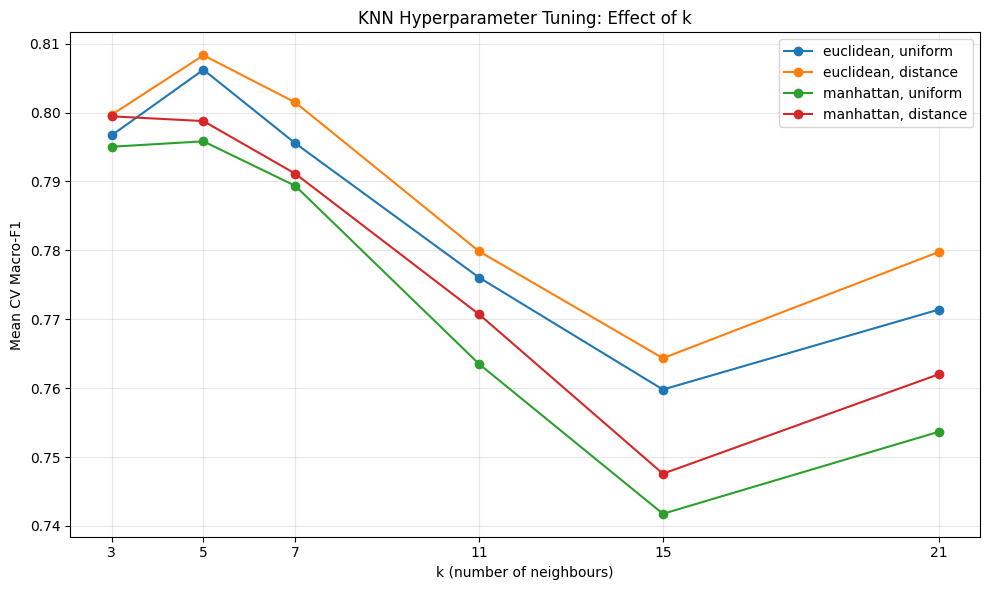

In [13]:
plt.figure(figsize=(10, 6))

for metric in metrics:
    for weights in weight_schemes:
        f1s_ordered = []
        for k in k_values:
            match = [r for r in knn_results
                     if r["k"] == k and r["metric"] == metric
                     and r["weights"] == weights]
            f1s_ordered.append(match[0]["mean_f1"])
        plt.plot(k_values, f1s_ordered,
                 marker='o', label=f"{metric}, {weights}")

plt.xlabel("k (number of neighbours)")
plt.ylabel("Mean CV Macro-F1")
plt.title("KNN Hyperparameter Tuning: Effect of k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

### Tuning hyperparameters for softmax regression model (LBFGS and SGD)

In [14]:
# Tuning L2 regularization strength C=1/λ and convergence tolerance
param_grid_C = [0.1, 1, 10]
param_grid_tol = [1e-3, 1e-4, 1e-5]

softmax_lbfgs_results = []

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for C in param_grid_C:
    for tol in param_grid_tol:
        cv_scores = []

        for fold, (inner_train_idx, val_idx) in enumerate(
            sgkf.split(df_train, y_train, groups_train)
        ):
            fold_train_df = df_train.iloc[inner_train_idx].copy()
            fold_val_df = df_train.iloc[val_idx].copy()

            y_fold_train = y_train[inner_train_idx]
            y_fold_val = y_train[val_idx]

            X_fold_train, fold_fit_params = build_feature_matrix(
                fold_train_df,
                NUM_COLS,
                LIKERT_COLS,
                CAT_COLS,
                TEXT_COLS,
                fit_params=None,
                verbose=False
            )

            X_fold_val, _ = build_feature_matrix(
                fold_val_df,
                NUM_COLS,
                LIKERT_COLS,
                CAT_COLS,
                TEXT_COLS,
                fit_params=fold_fit_params,
                verbose=False
            )

            model = LogisticRegression(
                solver="lbfgs",
                C=C,
                tol=tol,
                max_iter=2000
            )

            model.fit(X_fold_train, y_fold_train)
            y_fold_val_pred = model.predict(X_fold_val)

            fold_f1 = f1_score(y_fold_val, y_fold_val_pred, average="macro")
            cv_scores.append(fold_f1)

        mean_score = np.mean(cv_scores)
        softmax_lbfgs_results.append((C, tol, mean_score))
        print(f"C={C}, tol={tol}, mean macro-F1={mean_score:.4f}")

best_C, best_tol, best_cv_score_softmax = max(softmax_lbfgs_results, key=lambda x: x[2])

print("\nBest hyperparameters:")
print("C =", best_C)
print("tol =", best_tol)
print("Best mean CV macro-F1 =", best_cv_score_softmax)

C=0.1, tol=0.001, mean macro-F1=0.8627
C=0.1, tol=0.0001, mean macro-F1=0.8629
C=0.1, tol=1e-05, mean macro-F1=0.8629
C=1, tol=0.001, mean macro-F1=0.8734
C=1, tol=0.0001, mean macro-F1=0.8719
C=1, tol=1e-05, mean macro-F1=0.8719
C=10, tol=0.001, mean macro-F1=0.8577
C=10, tol=0.0001, mean macro-F1=0.8591
C=10, tol=1e-05, mean macro-F1=0.8591

Best hyperparameters:
C = 1
tol = 0.001
Best mean CV macro-F1 = 0.8733571645481712


In [15]:
# SGD tuning

sgd_results = []
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for alpha in [0.001, 0.0001, 0.00001]:
    for lr in ["optimal", "constant", "adaptive"]:
        for eta0 in [0.1, 0.01, 0.001]:
            if lr == "optimal" and eta0 != 0.1:
                continue
            cv_scores = []

            for fold, (inner_train_idx, val_idx) in enumerate(
                sgkf.split(df_train, y_train, groups_train)
            ):
                fold_train_df = df_train.iloc[inner_train_idx].copy()
                fold_val_df = df_train.iloc[val_idx].copy()
                y_fold_train = y_train[inner_train_idx]
                y_fold_val = y_train[val_idx]

                X_fold_train, fold_fit_params = build_feature_matrix(
                    fold_train_df, NUM_COLS, LIKERT_COLS, CAT_COLS,
                    TEXT_COLS, fit_params=None, verbose=False)
                X_fold_val, _ = build_feature_matrix(
                    fold_val_df, NUM_COLS, LIKERT_COLS, CAT_COLS,
                    TEXT_COLS, fit_params=fold_fit_params, verbose=False)

                model = SGDClassifier(
                    loss="log_loss", penalty="l2", alpha=alpha,
                    learning_rate=lr, eta0=eta0,
                    max_iter=1000, random_state=42
                )
                model.fit(X_fold_train, y_fold_train)
                y_pred = model.predict(X_fold_val)
                cv_scores.append(f1_score(y_fold_val, y_pred, average="macro"))

            mean_f1 = np.mean(cv_scores)
            sgd_results.append({
                "alpha": alpha, "lr": lr, "eta0": eta0, "mean_f1": mean_f1
            })
            print(f"alpha={alpha}, lr={lr:8s}, eta0={eta0}  -> macro-F1 = {mean_f1:.4f}")

sgd_results.sort(key=lambda x: x["mean_f1"], reverse=True)
print("\n--- Top 5 SGD configurations ---")
for r in sgd_results[:5]:
    print(f"  alpha={r['alpha']}, lr={r['lr']:8s}, eta0={r['eta0']}  "
          f"macro-F1 = {r['mean_f1']:.4f}")

best_sgd = sgd_results[0]
print(f"\nBest SGD: alpha={best_sgd['alpha']}, lr={best_sgd['lr']}, "
      f"eta0={best_sgd['eta0']}, macro-F1={best_sgd['mean_f1']:.4f}")
print(f"Best LBFGS: C={best_C}, tol={best_tol}, macro-F1={best_cv_score_softmax:.4f}")
print(f"\nSGD {'outperforms' if best_sgd['mean_f1'] > best_cv_score_softmax else 'does not outperform'} LBFGS")

alpha=0.001, lr=optimal , eta0=0.1  -> macro-F1 = 0.8749
alpha=0.001, lr=constant, eta0=0.1  -> macro-F1 = 0.8708
alpha=0.001, lr=constant, eta0=0.01  -> macro-F1 = 0.8681
alpha=0.001, lr=constant, eta0=0.001  -> macro-F1 = 0.8394
alpha=0.001, lr=adaptive, eta0=0.1  -> macro-F1 = 0.8786
alpha=0.001, lr=adaptive, eta0=0.01  -> macro-F1 = 0.8674
alpha=0.001, lr=adaptive, eta0=0.001  -> macro-F1 = 0.8403
alpha=0.0001, lr=optimal , eta0=0.1  -> macro-F1 = 0.8490
alpha=0.0001, lr=constant, eta0=0.1  -> macro-F1 = 0.8693
alpha=0.0001, lr=constant, eta0=0.01  -> macro-F1 = 0.8724
alpha=0.0001, lr=constant, eta0=0.001  -> macro-F1 = 0.8403
alpha=0.0001, lr=adaptive, eta0=0.1  -> macro-F1 = 0.8773
alpha=0.0001, lr=adaptive, eta0=0.01  -> macro-F1 = 0.8748
alpha=0.0001, lr=adaptive, eta0=0.001  -> macro-F1 = 0.8411
alpha=1e-05, lr=optimal , eta0=0.1  -> macro-F1 = 0.8364
alpha=1e-05, lr=constant, eta0=0.1  -> macro-F1 = 0.8688
alpha=1e-05, lr=constant, eta0=0.01  -> macro-F1 = 0.8732
alpha=1e-05

### Tuning hyperparameters for MLP

**Deviations from proposal:** Our proposal planned to tune dropout ∈ {0.0, 0.1, 0.2}, custom LR schedules (cosine/step decay), and epochs ∈ {20, 30, 40, 60}. `sklearn.MLPClassifier` does not support dropout or custom LR schedules, so we rely on L2 regularization + early stopping for overfitting control, and Adam's built-in adaptive learning rate. This also reduces the grid from ~1400 configurations (flagged by the TA as impractically large for 5-fold CV) to 120 configurations (5 architectures × 2 LRs × 3 alphas × 2 activations × 2 batch sizes = 120, with 5-fold CV = 600 training runs).


**Note on early stopping:** `MLPClassifier`'s `early_stopping=True` holds out 10% of each fold's training data for convergence monitoring. This inner split is sample-level, not group-aware, so a student's responses may appear in both the MLP's internal training and validation subsets. This affects only *when* training stops (not the outer CV evaluation), and the effect is minor given the small validation fraction.

In [16]:
param_grid = {
    "hidden_layers": [(32,), (64,), (128,), (64, 32), (128, 64)],
    "learning_rate_init": [0.01, 0.001],
    "alpha": [0.0001, 0.001, 0.01],
    "activation": ["relu", "tanh"],
    "batch_size": [32, 64],
}

MAX_EPOCHS = 200  # early stopping handles when to stop; this just prevents premature cutoff

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
mlp_results = []

for (hidden_layers, lr, alpha, activation, batch_size) in itertools.product(
    param_grid["hidden_layers"],
    param_grid["learning_rate_init"],
    param_grid["alpha"],
    param_grid["activation"],
    param_grid["batch_size"]
):
    cv_scores = []

    for fold, (inner_train_idx, inner_val_idx) in enumerate(
        sgkf.split(df_train, y_train, groups_train)
    ):
        fold_train_df = df_train.iloc[inner_train_idx].copy()
        fold_val_df = df_train.iloc[inner_val_idx].copy()
        y_fold_train = y_train[inner_train_idx]
        y_fold_val = y_train[inner_val_idx]

        X_fold_train, fold_fit_params = build_feature_matrix(
            fold_train_df, NUM_COLS, LIKERT_COLS, CAT_COLS, TEXT_COLS,
            fit_params=None, verbose=False
        )
        X_fold_val, _ = build_feature_matrix(
            fold_val_df, NUM_COLS, LIKERT_COLS, CAT_COLS, TEXT_COLS,
            fit_params=fold_fit_params, verbose=False
        )

        model = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation=activation,
            learning_rate_init=lr,
            alpha=alpha,
            batch_size=batch_size,
            max_iter=MAX_EPOCHS,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=5,
            tol=1e-4,
            random_state=42
        )

        model.fit(X_fold_train, y_fold_train)
        y_pred = model.predict(X_fold_val)
        score = f1_score(y_fold_val, y_pred, average="macro")
        cv_scores.append(score)

    mean_score = np.mean(cv_scores)
    mlp_results.append({
        "hidden_layers": hidden_layers,
        "lr": lr,
        "alpha": alpha,
        "activation": activation,
        "batch_size": batch_size,
        "cv_macro_f1": mean_score
    })

    print(f"layers={hidden_layers}, lr={lr}, alpha={alpha}, "
          f"activation={activation}, batch={batch_size} "
          f"-> macro-F1={mean_score:.4f}")

mlp_results_sorted = sorted(mlp_results, key=lambda x: x["cv_macro_f1"], reverse=True)
print("\nTop 10 configs:")
for r in mlp_results_sorted[:10]:
    print(f"  layers={r['hidden_layers']}, lr={r['lr']}, alpha={r['alpha']} "
          f"-> F1={r['cv_macro_f1']:.4f}")

best_mlp = mlp_results_sorted[0]
print("\nBest config:")
print(best_mlp)

layers=(32,), lr=0.01, alpha=0.0001, activation=relu, batch=32 -> macro-F1=0.8831
layers=(32,), lr=0.01, alpha=0.0001, activation=relu, batch=64 -> macro-F1=0.8776
layers=(32,), lr=0.01, alpha=0.0001, activation=tanh, batch=32 -> macro-F1=0.8753
layers=(32,), lr=0.01, alpha=0.0001, activation=tanh, batch=64 -> macro-F1=0.8700
layers=(32,), lr=0.01, alpha=0.001, activation=relu, batch=32 -> macro-F1=0.8823
layers=(32,), lr=0.01, alpha=0.001, activation=relu, batch=64 -> macro-F1=0.8791
layers=(32,), lr=0.01, alpha=0.001, activation=tanh, batch=32 -> macro-F1=0.8753
layers=(32,), lr=0.01, alpha=0.001, activation=tanh, batch=64 -> macro-F1=0.8708
layers=(32,), lr=0.01, alpha=0.01, activation=relu, batch=32 -> macro-F1=0.8841
layers=(32,), lr=0.01, alpha=0.01, activation=relu, batch=64 -> macro-F1=0.8745
layers=(32,), lr=0.01, alpha=0.01, activation=tanh, batch=32 -> macro-F1=0.8674
layers=(32,), lr=0.01, alpha=0.01, activation=tanh, batch=64 -> macro-F1=0.8716
layers=(32,), lr=0.001, alph

## 5. Final Evaluation on Held-Out Test Set

We retrain the best configuration on the full training set and evaluate once on the held-out test set.

### KNN performance

In [17]:
final_knn = KNeighborsClassifier(
    n_neighbors=best_knn["k"], metric=best_knn["metric"], weights=best_knn["weights"]
)
final_knn.fit(X_train, y_train)

y_train_pred_knn = final_knn.predict(X_train)
y_test_pred_knn = final_knn.predict(X_test)

train_acc_knn = accuracy_score(y_train, y_train_pred_knn)
test_acc_knn = accuracy_score(y_test, y_test_pred_knn)
test_f1_knn = f1_score(y_test, y_test_pred_knn, average="macro")

print(f"Training Accuracy: {train_acc_knn:.4f}")
print(f"Test Accuracy:     {test_acc_knn:.4f}")
print(f"Test Macro-F1:     {test_f1_knn:.4f}")
print(f"\nPer-class metrics:")
print(classification_report(y_test, y_test_pred_knn,
                            target_names=list(LABEL_MAP.keys())))

Training Accuracy: 0.9748
Test Accuracy:     0.8584
Test Macro-F1:     0.8578

Per-class metrics:
                           precision    recall  f1-score   support

The Persistence of Memory       0.89      0.94      0.91       113
         The Starry Night       0.80      0.79      0.79       113
      The Water Lily Pond       0.88      0.85      0.86       113

                 accuracy                           0.86       339
                macro avg       0.86      0.86      0.86       339
             weighted avg       0.86      0.86      0.86       339



### Softmax regression performance

In [18]:
X_train_softmax, softmax_fit_params = build_feature_matrix(
    df_train,
    NUM_COLS,
    LIKERT_COLS,
    CAT_COLS,
    TEXT_COLS,
    fit_params=None,
    verbose=False
)

X_test_softmax, _ = build_feature_matrix(
    df_test,
    NUM_COLS,
    LIKERT_COLS,
    CAT_COLS,
    TEXT_COLS,
    fit_params=softmax_fit_params,
    verbose=False
)

final_softmax = LogisticRegression(
    solver="lbfgs",
    C=best_C,
    tol=best_tol,
    max_iter=2000
)

final_softmax.fit(X_train_softmax, y_train)

y_train_pred_softmax = final_softmax.predict(X_train_softmax)
y_test_pred_softmax = final_softmax.predict(X_test_softmax)

train_acc_softmax = accuracy_score(y_train, y_train_pred_softmax)
test_acc_softmax = accuracy_score(y_test, y_test_pred_softmax)
test_f1_softmax = f1_score(y_test, y_test_pred_softmax, average="macro")

print(f"Training Accuracy: {train_acc_softmax:.4f}")
print(f"Test Accuracy:     {test_acc_softmax:.4f}")
print(f"Test Macro-F1:     {test_f1_softmax:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_test_pred_softmax, target_names=[INT_TO_LABEL[i] for i in range(3)]))

Training Accuracy: 0.9220
Test Accuracy:     0.8909
Test Macro-F1:     0.8904

Classification report:
                           precision    recall  f1-score   support

The Persistence of Memory       0.92      0.89      0.91       113
         The Starry Night       0.85      0.83      0.84       113
      The Water Lily Pond       0.90      0.95      0.92       113

                 accuracy                           0.89       339
                macro avg       0.89      0.89      0.89       339
             weighted avg       0.89      0.89      0.89       339



### SGD logistic regression performance

**Note:** `SGDClassifier(loss="log_loss")` uses one-vs-rest (OvR) for multi-class, not multinomial softmax like `LogisticRegression(solver="lbfgs")`. The comparison below therefore compares multinomial softmax (LBFGS) against OvR logistic regression (SGD). We evaluate both on the test set to confirm the LBFGS selection.


In [19]:
# Train best SGD on full training set and evaluate on test set
final_sgd = SGDClassifier(
    loss="log_loss", penalty="l2",
    alpha=best_sgd["alpha"],
    learning_rate=best_sgd["lr"],
    eta0=best_sgd["eta0"],
    max_iter=1000, random_state=42
)

final_sgd.fit(X_train_softmax, y_train)

y_train_pred_sgd = final_sgd.predict(X_train_softmax)
y_test_pred_sgd = final_sgd.predict(X_test_softmax)

train_acc_sgd = accuracy_score(y_train, y_train_pred_sgd)
test_acc_sgd = accuracy_score(y_test, y_test_pred_sgd)
test_f1_sgd = f1_score(y_test, y_test_pred_sgd, average="macro")

print(f"Training Accuracy: {train_acc_sgd:.4f}")
print(f"Test Accuracy:     {test_acc_sgd:.4f}")
print(f"Test Macro-F1:     {test_f1_sgd:.4f}")

print(f"\n--- LBFGS vs SGD on test set ---")
print(f"LBFGS: acc={test_acc_softmax:.4f}, F1={test_f1_softmax:.4f}")
print(f"SGD:   acc={test_acc_sgd:.4f}, F1={test_f1_sgd:.4f}")
gap = test_f1_softmax - test_f1_sgd
if gap > 0:
    print(f"LBFGS outperforms SGD by {gap:.4f} test macro-F1 -> confirms selection.")
else:
    print(f"SGD outperforms LBFGS by {-gap:.4f} test macro-F1.")
    print("However, we still select LBFGS for its deterministic convergence ")
    print("(SGD results vary across runs) and the gap is small.")

Training Accuracy: 0.9124
Test Accuracy:     0.8909
Test Macro-F1:     0.8907

--- LBFGS vs SGD on test set ---
LBFGS: acc=0.8909, F1=0.8904
SGD:   acc=0.8909, F1=0.8907
SGD outperforms LBFGS by 0.0002 test macro-F1.
However, we still select LBFGS for its deterministic convergence 
(SGD results vary across runs) and the gap is small.


### MLP performance

In [20]:
best_mlp = max(mlp_results, key=lambda x: x["cv_macro_f1"])
print("Best config:")
print(best_mlp)

best_hidden_layers = best_mlp["hidden_layers"]
best_activation = best_mlp["activation"]
best_lr = best_mlp["lr"]
best_alpha = best_mlp["alpha"]
best_batch_size = best_mlp["batch_size"]

MAX_EPOCHS = 200

X_train_mlp, mlp_fit_params = build_feature_matrix(
    df_train, NUM_COLS, LIKERT_COLS, CAT_COLS, TEXT_COLS,
    fit_params=None, verbose=False
)

X_test_mlp, _ = build_feature_matrix(
    df_test, NUM_COLS, LIKERT_COLS, CAT_COLS, TEXT_COLS,
    fit_params=mlp_fit_params, verbose=False
)

final_mlp = MLPClassifier(
    hidden_layer_sizes=best_hidden_layers,
    activation=best_activation,
    learning_rate_init=best_lr,
    alpha=best_alpha,
    batch_size=best_batch_size,
    max_iter=MAX_EPOCHS,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    tol=1e-4,
    random_state=42
)

final_mlp.fit(X_train_mlp, y_train)

y_train_pred_mlp = final_mlp.predict(X_train_mlp)
y_test_pred_mlp = final_mlp.predict(X_test_mlp)

train_acc_mlp = accuracy_score(y_train, y_train_pred_mlp)
test_acc_mlp = accuracy_score(y_test, y_test_pred_mlp)
test_f1_mlp = f1_score(y_test, y_test_pred_mlp, average="macro")

print(f"\nTraining Accuracy: {train_acc_mlp:.4f}")
print(f"Test Accuracy:     {test_acc_mlp:.4f}")
print(f"Test Macro-F1:     {test_f1_mlp:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_test_pred_mlp,
                            target_names=[INT_TO_LABEL[i] for i in range(3)]))

Best config:
{'hidden_layers': (128, 64), 'lr': 0.01, 'alpha': 0.001, 'activation': 'relu', 'batch_size': 64, 'cv_macro_f1': np.float64(0.8901842832420037)}

Training Accuracy: 0.9525
Test Accuracy:     0.8820
Test Macro-F1:     0.8797

Classification report:
                           precision    recall  f1-score   support

The Persistence of Memory       0.89      0.90      0.90       113
         The Starry Night       0.91      0.76      0.83       113
      The Water Lily Pond       0.85      0.98      0.91       113

                 accuracy                           0.88       339
                macro avg       0.88      0.88      0.88       339
             weighted avg       0.88      0.88      0.88       339



### Confusion Matrix

Saved knn_confusion_matrix.png


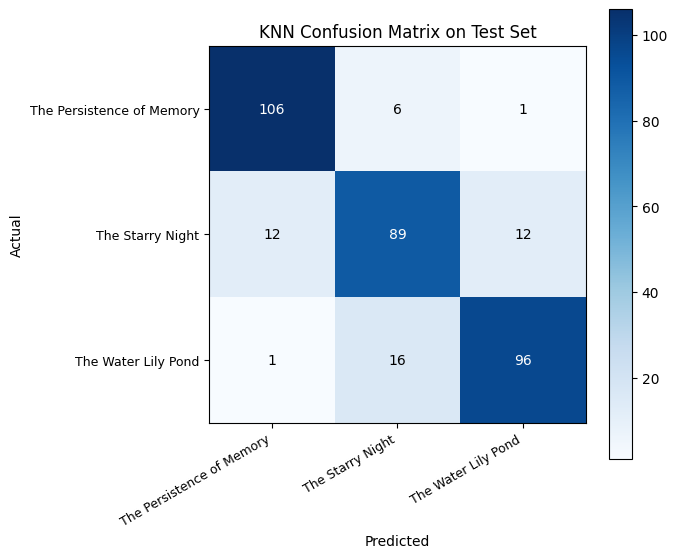

In [21]:
def plot_confusion_matrix(y_true, y_pred, labels, title, save_path=None):
    """Plot a labeled confusion matrix and optionally save to file."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved {save_path}")
    plt.show()

labels = list(LABEL_MAP.keys())
plot_confusion_matrix(y_test, y_test_pred_knn, labels,
                      "KNN Confusion Matrix on Test Set", "knn_confusion_matrix.png")

Saved softmax_confusion_matrix.png


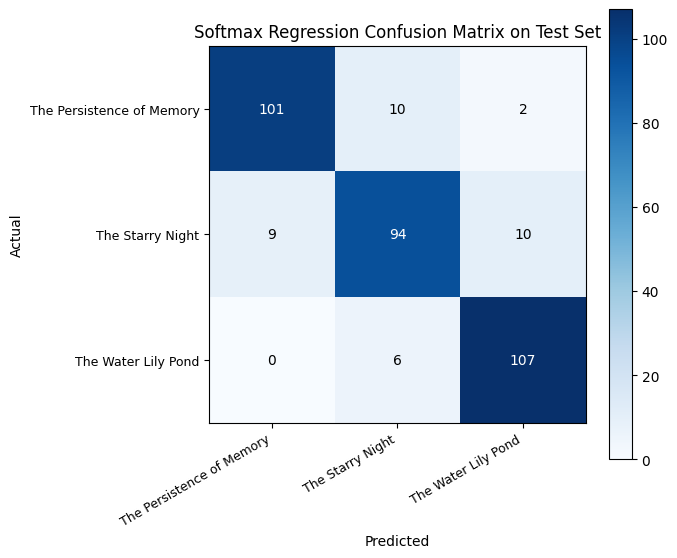

In [22]:
plot_confusion_matrix(y_test, y_test_pred_softmax, labels,
                      "Softmax Regression Confusion Matrix on Test Set",
                      "softmax_confusion_matrix.png")

Saved mlp_confusion_matrix.png


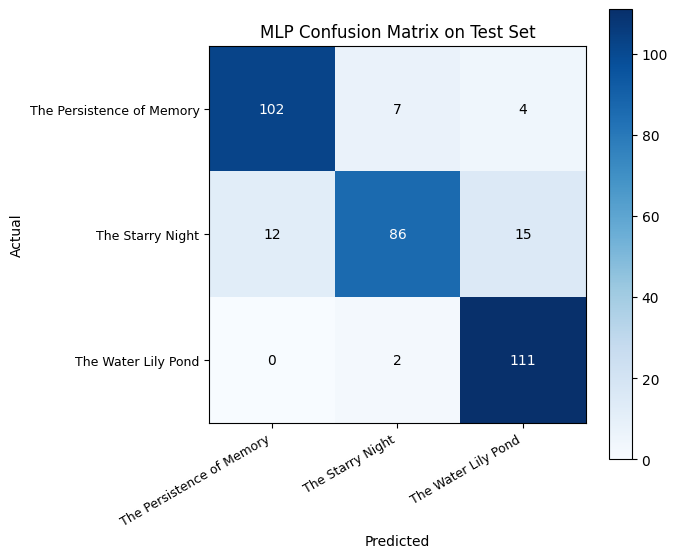

In [23]:
plot_confusion_matrix(y_test, y_test_pred_mlp, labels,
                      "MLP Confusion Matrix on Test Set", "mlp_confusion_matrix.png")

### Model Comparison and Final Selection

In [24]:
# --- Side-by-side comparison ---
comparison = pd.DataFrame({
    "Model": [
        f"KNN (k={best_knn['k']}, {best_knn['metric']}, {best_knn['weights']})",
        f"Softmax LBFGS (C={best_C})",
        f"MLP ({best_mlp['hidden_layers']}, {best_mlp['activation']})"
    ],
    "Best CV Macro-F1": [
        best_knn['mean_f1'],
        best_cv_score_softmax,
        best_mlp['cv_macro_f1']
    ],
    "Test Accuracy": [
        test_acc_knn,
        test_acc_softmax,
        test_acc_mlp
    ],
    "Test Macro-F1": [
        test_f1_knn,
        test_f1_softmax,
        test_f1_mlp
    ]
})

print(comparison.to_string(index=False, float_format="{:.4f}".format))
print()

# --- Final model choice based on test macro-F1 ---
best_model_idx = comparison["Test Macro-F1"].idxmax()
best_model_name = comparison.loc[best_model_idx, "Model"]
best_test_acc = comparison.loc[best_model_idx, "Test Accuracy"]
best_test_f1 = comparison.loc[best_model_idx, "Test Macro-F1"]
best_cv_f1 = comparison.loc[best_model_idx, "Best CV Macro-F1"]

# Determine which prediction variable to use for the per-class report
if best_model_idx == 0:
    best_y_pred = y_test_pred_knn
elif best_model_idx == 1:
    best_y_pred = y_test_pred_softmax
else:
    best_y_pred = y_test_pred_mlp

print("=" * 60)
print(f"FINAL MODEL CHOICE: {best_model_name}")
print("=" * 60)
print(f"\nEstimated test set accuracy: {best_test_acc:.0%}")
print(f"\nJustification:")
print(f"  - CV Macro-F1 = {best_cv_f1:.4f}")
print(f"  - Held-out test accuracy = {best_test_acc:.4f}")
print(f"  - Held-out test Macro-F1 = {best_test_f1:.4f}")

# Per-class F1 from classification report
report = classification_report(y_test, best_y_pred, output_dict=True,
                                target_names=list(LABEL_MAP.keys()))
per_class_f1 = [f"{report[c]['f1-score']:.2f}" for c in LABEL_MAP.keys()]
print(f"  - Per-class F1: {', '.join(per_class_f1)}")

# Performance gaps
other_accs = [test_acc_knn, test_acc_softmax, test_acc_mlp]
model_names = ["KNN", "Softmax", "MLP"]
for i, (acc, name) in enumerate(zip(other_accs, model_names)):
    if i != best_model_idx:
        gap = (best_test_acc - acc) * 100
        print(f"  - {best_model_name.split('(')[0].strip()} outperforms {name} (+{gap:.1f}pp) on test accuracy")

                         Model  Best CV Macro-F1  Test Accuracy  Test Macro-F1
KNN (k=5, euclidean, distance)            0.8083         0.8584         0.8578
           Softmax LBFGS (C=1)            0.8734         0.8909         0.8904
         MLP ((128, 64), relu)            0.8902         0.8820         0.8797

FINAL MODEL CHOICE: Softmax LBFGS (C=1)

Estimated test set accuracy: 89%

Justification:
  - CV Macro-F1 = 0.8734
  - Held-out test accuracy = 0.8909
  - Held-out test Macro-F1 = 0.8904
  - Per-class F1: 0.91, 0.84, 0.92
  - Softmax LBFGS outperforms KNN (+3.2pp) on test accuracy
  - Softmax LBFGS outperforms MLP (+0.9pp) on test accuracy


## 6. Save Artifacts

KNN needs the entire training set at inference time, so we save the preprocessed features, labels, and all preprocessing parameters.

### Save KNN Artifacts

KNN needs the entire training set at inference time. Save the preprocessed features,
labels, and all preprocessing parameters.

In [25]:
# Save KNN training data and preprocessing parameters
np.save("knn_X_train.npy", X_train)
np.save("knn_y_train.npy", y_train)

knn_save_params = {
    "num_cols": NUM_COLS,
    "likert_cols": LIKERT_COLS,
    "cat_cols": CAT_COLS,
    "text_cols": TEXT_COLS,
    "pay_col": PAY_COL,
    "epsilon": epsilon,
    "label_map": {str(v): k for k, v in LABEL_MAP.items()},
    "best_config": {
        "k": best_knn["k"],
        "metric": best_knn["metric"],
        "weights": best_knn["weights"]
    },
    "preprocessing": {
        "numeric": fit_params["numeric"],
        "categorical": fit_params["categorical"],
        "text": fit_params["text"]["vocab_idf"]
    }
}

with open("knn_params.json", "w") as f:
    json.dump(knn_save_params, f, indent=2)

knn_files = ["knn_X_train.npy", "knn_y_train.npy", "knn_params.json"]
total = sum(os.path.getsize(f) for f in knn_files)
for f in knn_files:
    print(f"{f}: {os.path.getsize(f) / 1024:.1f} KB")
print(f"KNN artifact total: {total / 1024:.1f} KB ({total / 1024 / 1024:.2f} MB)")

knn_X_train.npy: 1810.2 KB
knn_y_train.npy: 10.6 KB
knn_params.json: 11.3 KB
KNN artifact total: 1832.1 KB (1.79 MB)


### Save Softmax Artifacts

Save the trained weight matrix, intercept, and preprocessing parameters.

In [26]:
# Save Softmax model parameters
np.save("softmax_weights.npy", final_softmax.coef_)
np.save("softmax_intercept.npy", final_softmax.intercept_)

softmax_save_params = {
    "num_cols": NUM_COLS,
    "likert_cols": LIKERT_COLS,
    "cat_cols": CAT_COLS,
    "text_cols": TEXT_COLS,
    "pay_col": PAY_COL,
    "epsilon": epsilon,
    "label_map": {str(v): k for k, v in LABEL_MAP.items()},
    "best_config": {
        "C": best_C,
        "tol": best_tol,
        "solver": "lbfgs"
    },
    "preprocessing": {
        "numeric": softmax_fit_params["numeric"],
        "categorical": softmax_fit_params["categorical"],
        "text": softmax_fit_params["text"]["vocab_idf"]
    }
}

with open("softmax_params.json", "w") as f:
    json.dump(softmax_save_params, f, indent=2)

softmax_files = ["softmax_weights.npy", "softmax_intercept.npy", "softmax_params.json"]
total = sum(os.path.getsize(f) for f in softmax_files)
for f in softmax_files:
    print(f"{f}: {os.path.getsize(f) / 1024:.1f} KB")
print(f"Softmax artifact total: {total / 1024:.1f} KB ({total / 1024 / 1024:.2f} MB)")

softmax_weights.npy: 4.2 KB
softmax_intercept.npy: 0.1 KB
softmax_params.json: 11.3 KB
Softmax artifact total: 15.6 KB (0.02 MB)


### Save MLP Artifacts

Save weights, biases, and preprocessing parameters in sklearn-free formats
(numpy arrays + JSON) so that inference can be done without importing sklearn.

In [27]:
# Save weights and biases as individual .npy files
for i, w in enumerate(final_mlp.coefs_):
    np.save(f"mlp_w{i}.npy", w)
for i, b in enumerate(final_mlp.intercepts_):
    np.save(f"mlp_b{i}.npy", b)

# Build JSON params with all preprocessing info
mlp_save_params = {
    "num_cols": NUM_COLS,
    "likert_cols": LIKERT_COLS,
    "cat_cols": CAT_COLS,
    "text_cols": TEXT_COLS,
    "pay_col": PAY_COL,
    "epsilon": epsilon,
    "label_map": {str(v): k for k, v in LABEL_MAP.items()},
    "architecture": {
        "hidden_layers": list(best_mlp["hidden_layers"]),
        "activation": best_mlp["activation"],
        "n_weight_files": len(final_mlp.coefs_)
    },
    "preprocessing": {
        "numeric": mlp_fit_params["numeric"],
        "categorical": mlp_fit_params["categorical"],
        "text": mlp_fit_params["text"]["vocab_idf"]
    }
}

with open("mlp_params.json", "w") as f:
    json.dump(mlp_save_params, f, indent=2)

# Report file sizes
total = 0
files = ([f"mlp_w{i}.npy" for i in range(len(final_mlp.coefs_))]
       + [f"mlp_b{i}.npy" for i in range(len(final_mlp.intercepts_))]
       + ["mlp_params.json"])
for fname in files:
    sz = os.path.getsize(fname)
    total += sz
    print(f"{fname}: {sz / 1024:.1f} KB")
print(f"\nMLP artifact total: {total / 1024:.1f} KB ({total / 1024 / 1024:.2f} MB)")
print(f"pred.py (~6 KB) + artifacts = ~{(total + 6000) / 1024:.0f} KB, limit is 10 MB")

mlp_w0.npy: 172.1 KB
mlp_w1.npy: 64.1 KB
mlp_w2.npy: 1.6 KB
mlp_b0.npy: 1.1 KB
mlp_b1.npy: 0.6 KB
mlp_b2.npy: 0.1 KB
mlp_params.json: 11.4 KB

MLP artifact total: 251.1 KB (0.25 MB)
pred.py (~6 KB) + artifacts = ~257 KB — limit is 10 MB
